## Домашнее задание 2

Первая содержательная домашка по smr. Рекомендую сесть за нее заранее, чтобы прочувствовать.

Пользоваться никакими нейросетями для написания кода контроллеров или вообще какого-либо осмысленного кода не нужно. Можно гуглить, можно спрашивать нейросети про визуализацию. Но только про неё!

Загрузить .ipynb файл нужно будет в Google Classroom курса до дедлайна.

### Задача 1

Продолжите работу над семинарским кодом.
Подпишите оси на графиках :)

Попробуйте найти параметры PD-регулятора, при которых стабилизация системы происходит наиболее быстро. (пока что просто попробуйте поменять значения руками и почувствуйте, как это влияет на траектории)

In [1]:
import matplotlib.pyplot as plt

In [2]:
y = 3  # координата
yd = 1  #  скорость
m = 5  # масса
dt = 0.01  # период дискретизации симуляции

iter_num = 10000  # число шагов симуляции
yhist, ydhist, uhist, thist = [], [], [], []  # логи(история всего)

Kp, Kd = 8, 3

for i in range(iter_num):
    u = - Kp * y - Kd * yd

    ydd = u / m

    y += yd * dt
    yd += ydd * dt

    yhist.append(y)
    ydhist.append(yd)
    uhist.append(u)
    thist.append(i * dt)

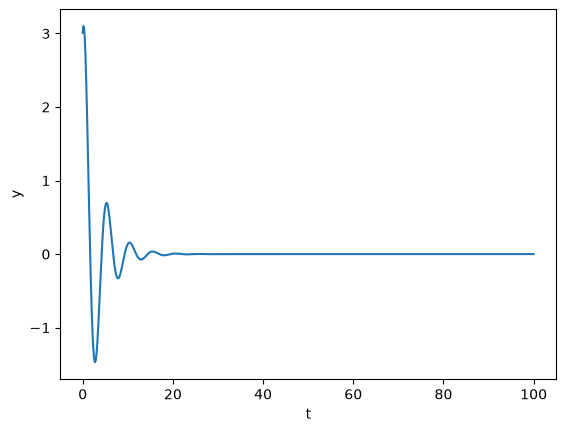

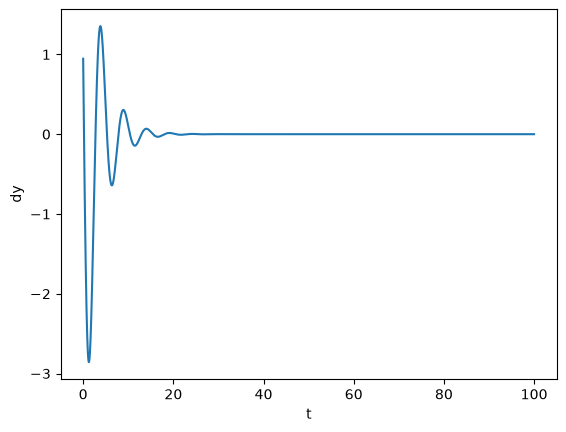

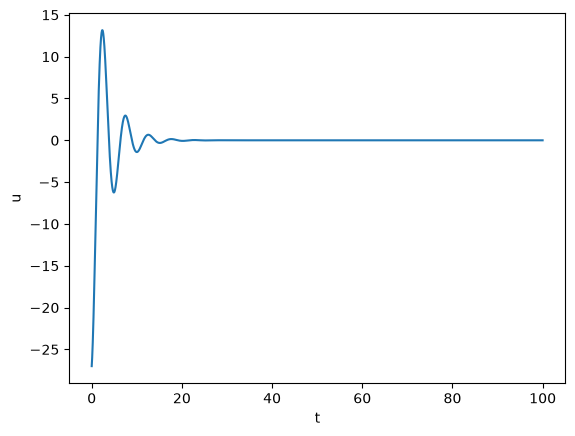

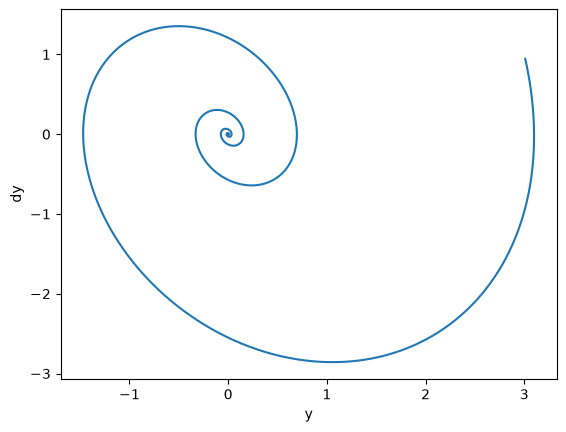

In [3]:
plt.plot(thist, yhist)
plt.xlabel('t')
plt.ylabel('y')
plt.show()
plt.plot(thist, ydhist)
plt.xlabel('t')
plt.ylabel('dy')
plt.show()
plt.plot(thist, uhist)
plt.xlabel('t')
plt.ylabel('u')
plt.show()
plt.plot(yhist, ydhist)
plt.xlabel('y')
plt.ylabel('dy')
plt.show()


### Задача 2

Реализуйте функцию, позволяющую найти время стабилизации по записанной траектории.

Функция принимает на вход:
- лист с координатой x от времени
- лист со скоростью от времени
- лист с отсчетами времени
- допуск по координате (если точка в +- 10 см от целевой координаты, то можно считать, что она приехала)
- допуск по скорости

Допуски можно в коде назвать coordinate_tolerance и velocity_tolerance

Функция должна вернуть первый такой момент времени, после которого ни координата, ни скорость не выходили за пределы допусков. Протестируйте свою функцию на траекториях системы.

Измерьте время стабилизации для разных комбинаций $K_p$ и $K_d$. Визуализируйте его в виде тепловой карты (heat map). Какие выводы напрашиваются при взгляде на эту карту?

In [4]:
def stabilizatiton_time(xhist, xdhist, thist, coord_toler, speed_toler):
    for i in range(len(xhist)):
        if abs(xdhist[i]) < speed_toler and abs(xhist[i]) < coord_toler:
            return thist[i]
    return 101



In [5]:
stabilizatiton_time(yhist, ydhist, thist, 0.01, 0.01)

19.85

In [6]:
def exec_sim(Kp, Kd):
    y = 3  # координата
    yd = 1  #  скорость
    m = 5  # масса
    dt = 0.01  # период дискретизации симуляции
    
    iter_num = 10000  # число шагов симуляции
    yhist, ydhist, uhist, thist = [], [], [], []  # логи(история всего)
    
    for i in range(iter_num):
        u = - Kp * y - Kd * yd
    
        ydd = u / m
    
        y += yd * dt
        yd += ydd * dt
    
        yhist.append(y)
        ydhist.append(yd)
        uhist.append(u)
        thist.append(i * dt)
    return yhist, ydhist, uhist, thist

In [7]:
klist = []
i = 0
while i <= 5:
    klist.append(i)
    i += 0.1

In [8]:
stab_time_hist = []
for kp in klist:
    stab_time_hist.append([])
    for kd in klist:
        yhist, ydhist, uhist, thist = exec_sim(kp, kd)
        st = stabilizatiton_time(yhist, ydhist, thist, 0.01, 0.01)
        stab_time_hist[-1].append(st)
        #print(kp, kd, st)

In [9]:
yhist, ydhist, uhist, thist = exec_sim(0.1, 0.7)
st = stabilizatiton_time(yhist, ydhist, thist, 0.01, 0.01)
st

72.93

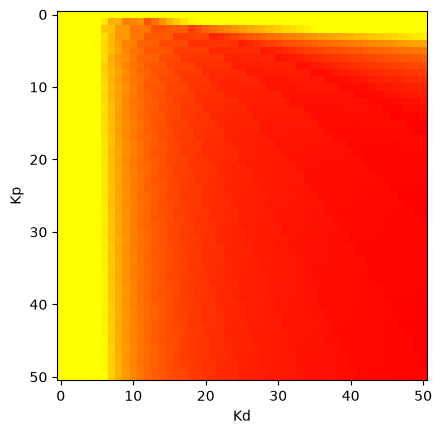

In [10]:
plt.imshow(stab_time_hist, cmap='autumn')
plt.xlabel('Kd')
plt.ylabel('Kp')
plt.show()

_Вывод:_ K_d нужен обязательно, не менее 0.7. Чем больше коэфы, тем быстрее сходимость системы.

### Задача 3

Теперь ограничьте максимальную силу, с которой контроллер может действовать на точку. Это можно сделать с помощью *np.clip* перед вычислением мгновенного ускорения в цикле управления. Измерьте время стабилизации для разных параметров контроллера снова. Что изменилось?

In [11]:
import numpy as np

In [12]:
def exec_sim(Kp, Kd):
    y = 3  # координата
    yd = 1  #  скорость
    m = 5  # масса
    dt = 0.01  # период дискретизации симуляции
    
    iter_num = 10000  # число шагов симуляции
    yhist, ydhist, uhist, thist = [], [], [], []  # логи(история всего)
    
    for i in range(iter_num):
        u = np.clip(- Kp * y - Kd * yd, -2, 2)
    
        ydd = u / m
    
        y += yd * dt
        yd += ydd * dt
    
        yhist.append(y)
        ydhist.append(yd)
        uhist.append(u)
        thist.append(i * dt)
    return yhist, ydhist, uhist, thist

In [13]:
klist = []
i = 0
while i <= 5:
    klist.append(i)
    i += 0.1

In [14]:
stab_time_hist = []
for kp in klist:
    stab_time_hist.append([])
    for kd in klist:
        yhist, ydhist, uhist, thist = exec_sim(kp, kd)
        st = stabilizatiton_time(yhist, ydhist, thist, 0.01, 0.01)
        stab_time_hist[-1].append(st)
        #print(kp, kd, st)

In [15]:
yhist, ydhist, uhist, thist = exec_sim(0.1, 0.7)
st = stabilizatiton_time(yhist, ydhist, thist, 0.01, 0.01)
st

72.93

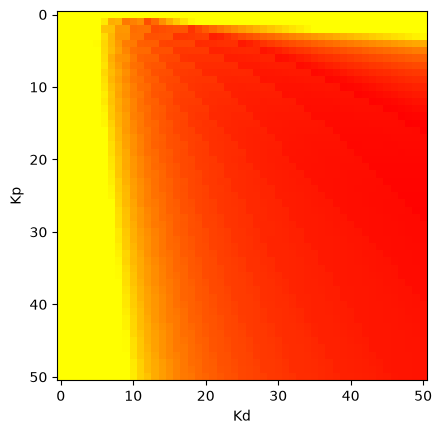

In [16]:
plt.imshow(stab_time_hist, cmap='autumn')
plt.xlabel('Kd')
plt.ylabel('Kp')
plt.show()

_Вывод_: Теперь для бОльших K_p нужен бОльший K_d

### Задача 4

Реализуйте функцию, вычисляющую стоимость траектории.
На вход ей поступает лист координат от времени, лист скоростей от времени, лист сил от времени и dt. На выход она отдает стоимость траектории.
Стоимость всего квадратична. Находиться в $m$ метрах от начала координат в течение одной секунды стоит $3 m^2$, двигаться со скоростью $v$ метров в секунду в течении одной секунды стоит $5 v^2$, прикладывать силу в $n$ ньютонов в течение одной текунды стоит $8 n^2$.

Протестируйте свою функцию на траекториях точки с массой, которую стабилизирует PD-контроллер с разными коэффициентами.

Попробуйте минимизировать стоимость траектории, варьируя $K_p$ и $K_d$ (можно руками, можно с помощью grid search, можно градиентным спуском, можно еще как-то, про что я не догадался).

In [17]:
def traj_cost(yhist, ydhist, uhist, dt):
    cost = 0
    for i in range(len(yhist)):
        cost += (3*yhist[i]**2 + 5*uhist[i]**2 + 8*uhist[i]**2) * dt
    return cost


In [18]:
yhist, ydhist, uhist, thist = exec_sim(0.1, 0.7)
print(traj_cost(yhist, ydhist, uhist, 0.01))
yhist, ydhist, uhist, thist = exec_sim(0.7, 0.1)
print(traj_cost(yhist, ydhist, uhist, 0.01))
yhist, ydhist, uhist, thist = exec_sim(1.5, 0.7)
print(traj_cost(yhist, ydhist, uhist, 0.01))
yhist, ydhist, uhist, thist = exec_sim(2, 0.3)
print(traj_cost(yhist, ydhist, uhist, 0.01))
yhist, ydhist, uhist, thist = exec_sim(5, 3)
print(traj_cost(yhist, ydhist, uhist, 0.01))


1247.3946302563186
3759.8743232889087
1562.0497332062523
4466.58879143766
1343.5410999226158


In [20]:
klist = []
i = 0
while i <= 5:
    klist.append(i)
    i += 0.1

In [21]:
cost_hist = []
kp_eff, kd_eff = 0, 0
min_cost = 10**100
for kp in klist:
    cost_hist.append([])
    for kd in klist:
        yhist, ydhist, uhist, thist = exec_sim(kp, kd)
        cost = traj_cost(yhist, ydhist, uhist, 0.01)
        if cost < min_cost:
            min_cost = cost
            kp_eff, kd_eff = kp, kd
        cost_hist[-1].append(cost_hist)
        #print(kp, kd, st)

In [22]:
kp_eff, kd_eff

(0.5, 2.3000000000000007)

In [24]:
yhist, ydhist, uhist, thist = exec_sim(kp_eff, kd_eff)
print(traj_cost(yhist, ydhist, uhist, 0.01))

489.4572853153033


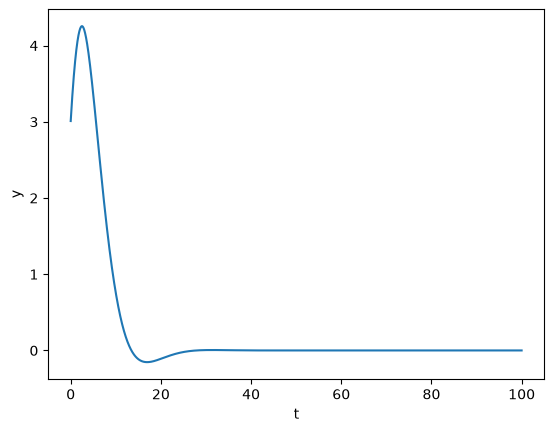

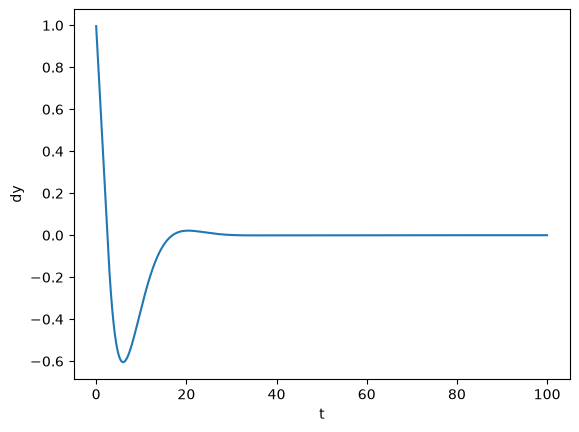

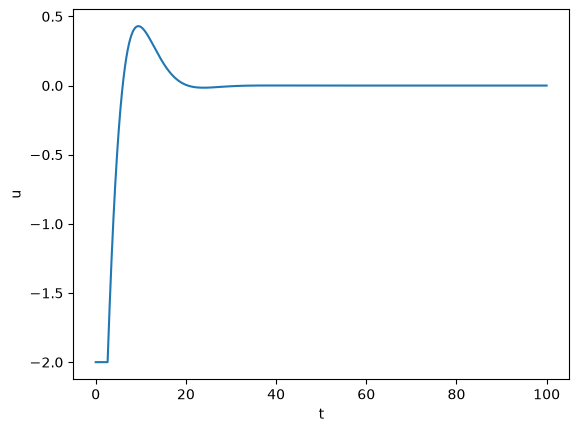

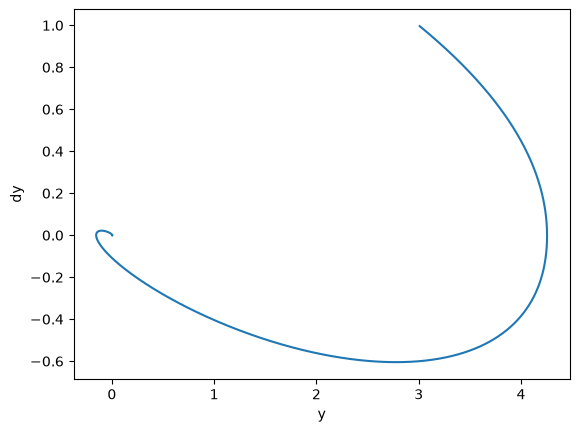

In [25]:
plt.plot(thist, yhist)
plt.xlabel('t')
plt.ylabel('y')
plt.show()
plt.plot(thist, ydhist)
plt.xlabel('t')
plt.ylabel('dy')
plt.show()
plt.plot(thist, uhist)
plt.xlabel('t')
plt.ylabel('u')
plt.show()
plt.plot(yhist, ydhist)
plt.xlabel('y')
plt.ylabel('dy')
plt.show()


### Задача 5

Покажите, что квадратная матрица $A$ коммутирует с $e^A$.

$$Ae^A = e^AA$$

$$e^A = \sum_{k=0}^{\infty} \frac{1}{k!} A^k$$

$$A\sum_{k=0}^{\infty} \frac{1}{k!} A^k = (\sum_{k=0}^{\infty} \frac{1}{k!} A^k)A$$

$$\sum_{k=0}^{\infty} A\frac{1}{k!} A^k = \sum_{k=0}^{\infty} \frac{1}{k!} A^kA$$

$$\sum_{k=0}^{\infty} \frac{1}{k!} A^{k+1}= \sum_{k=0}^{\infty} \frac{1}{k!} A^{k+1}$$

### Задача 6

Рассмотрим модель пружинного маятника на горизонтальной плоскости.

Его вектор состояния имеет вид

$x = \begin{pmatrix}
p \\
\dot{p} 
\end{pmatrix}$

Уравнение динамики системы в непрерывном случае таково:

$
\dot{x} = \begin{pmatrix}
0 & 1 \\
{- \frac{k}{m}} & 0 
\end{pmatrix} x
$

Пусть симуляция этой системы производится как

$x_{k+1} = x_k + \Delta t \dot{x}_k$

Найдите, как изменяется полная энергия системы за один шаг симуляции.

YOUR MARKDOWN HERE
$\( F = ma \)$
$\[ \ddot{x} + \omega^2 x = 0 \]$
